**Computación Cuántica II**
# Sebastián González Juárez
Práctica de laboratorio 4.

# **1.b. Corre Berstein Vazirani para el string que tu desees. E implementa los modelos indicados de ruido**

En este inciso se implementa el algoritmo de Bernstein-Vazirani para la cadena **s = 1111**.

Primero haré el circuito ideal, sin ruido, para verificar que el algoritmo recupera correctamente el string secreto. Y, ya después, se repite la simulación incorporando los tres modelos de ruido:

- Bit-flip
- Phase-flip
- Depolarizing channel

In [ ]:
!pip install qiskit qiskit-aer pylatexenc -q

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, pauli_error, depolarizing_error
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

## Circuito de Bernstein-Vazirani

In [ ]:
def bernstein_vazirani(secret_string):

    # Número de bits del string secreto
    n = len(secret_string)

    # n qubits de entrada + 1 auxiliar
    qc = QuantumCircuit(n + 1, n)

    # El auxiliar se prepara en |1>
    qc.x(n)

    # Hadamard en todos los qubits
    for q in range(n + 1):
        qc.h(q)

    # Oráculo
    for i, bit in enumerate(reversed(secret_string)):

        # Si el bit del string es 1,
        # aplicamos CX hacia el auxiliar
        if bit == "1":
            qc.cx(i, n)

    # Hadamard final
    for q in range(n):
        qc.h(q)

    # Mediciones
    for q in range(n):
        qc.measure(q, q)

    return qc

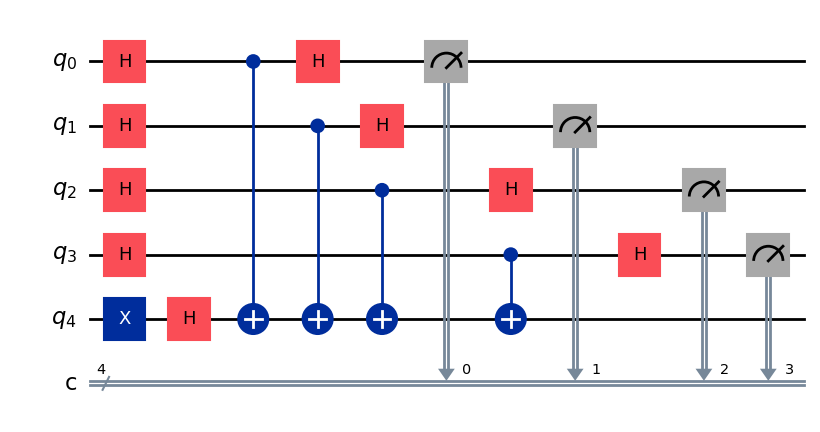

In [ ]:
# String secreto
s = "1111"

# Número de shots
shots = 4096

# Construimos el circuito
qc = bernstein_vazirani(s)

# Dibujamos el circuito
qc.draw("mpl")

Resultados ideales:
{'1111': 4096}


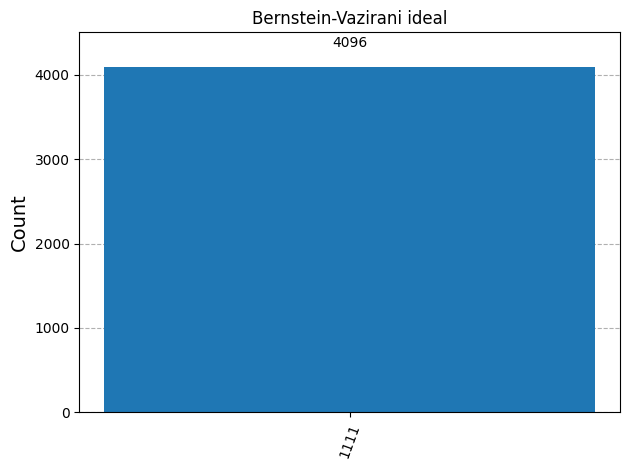

In [ ]:
# Simulador ideal
sim_ideal = AerSimulator()

# Transpilamos el circuito
qc_ideal = transpile(qc, sim_ideal)

# Ejecutamos
result_ideal = sim_ideal.run(
    qc_ideal,
    shots=shots
).result()

# Obtenemos cuentas
counts_ideal = result_ideal.get_counts()

# Mostramos resultados
print("Resultados ideales:")
print(counts_ideal)

# Histograma
fig = plot_histogram(
    counts_ideal,
    title="Bernstein-Vazirani ideal"
)

display(fig)

Y como esperabamos, el resultado esperado es: 1111.

## i. Bit-flip con p=0.2 en las compuertas H

El canal bit-flip introduce un error $X$ con probabilidad $p$:

$$
\rho \mapsto (1-p)\rho + p \, X\rho X
$$

En este caso, el error se aplicará únicamente sobre las compuertas Hadamard.

Resultados con Bit-flip:
{'0000': 9, '0001': 21, '1010': 97, '1111': 1661, '1000': 23, '0110': 83, '1101': 426, '1100': 106, '1011': 432, '0111': 413, '0011': 98, '1110': 466, '1001': 99, '0101': 101, '0100': 37, '0010': 24}


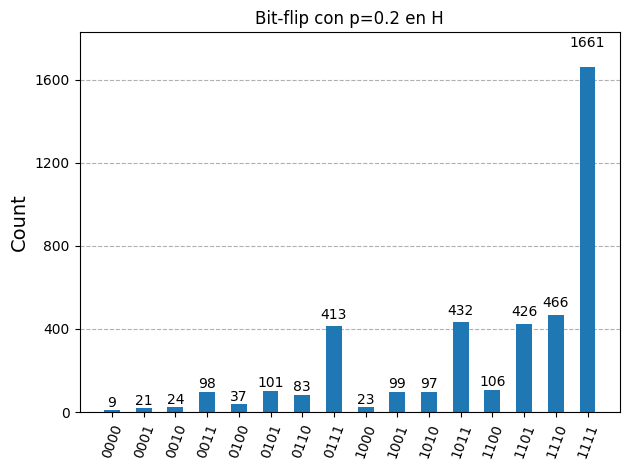

In [ ]:
# Modelo de ruido
noise_bitflip = NoiseModel()

# Probabilidad de error
p_bitflip = 0.2

# Error bit-flip
error_bitflip = pauli_error([
    ("X", p_bitflip),
    ("I", 1 - p_bitflip)
])

# Agregamos el error únicamente a las H
noise_bitflip.add_all_qubit_quantum_error(
    error_bitflip,
    ["h"]
)

# Simulador con ruido
sim_bitflip = AerSimulator(
    noise_model=noise_bitflip
)

# Transpilamos
qc_bitflip = transpile(qc, sim_bitflip)

# Ejecutamos
result_bitflip = sim_bitflip.run(
    qc_bitflip,
    shots=shots
).result()

# Resultados
counts_bitflip = result_bitflip.get_counts()

print("Resultados con Bit-flip:")
print(counts_bitflip)

# Histograma
fig = plot_histogram(
    counts_bitflip,
    title="Bit-flip con p=0.2 en H"
)

display(fig)

Así que vemos que para el caso del bit-flip con $p=0.2$, el string correcto $1111$ sigue siendo el resultado más frecuente, pero ya no aparece con probabilidad perfecta debido a los errores introducidos en las compuertas Hadamard.

Interpreto que como estas compuertas son las responsables de crear la superposición y recuperar la información final, cualquier modificación accidental afecta directamente el resultado medido. Esto explica por qué aparecen muchos estados cercanos a $1111$, como $1110$, $1101$ o $1011$, donde solo uno de los bits cambió por efecto del ruido.

## ii. Phase-flip en todas las compuertas unitarias

El phase-flip introduce un error $Z$ con probabilidad $p$:

$$
\rho \mapsto (1-p)\rho + p \, Z\rho Z
$$

Use $p = 0.2$.

Resultados con Phase-flip:
{'0010': 183, '0001': 271, '0000': 234, '1100': 173, '1111': 456, '1101': 277, '1000': 166, '0110': 236, '1110': 278, '1001': 239, '0101': 262, '1011': 296, '0111': 376, '0011': 316, '0100': 163, '1010': 170}


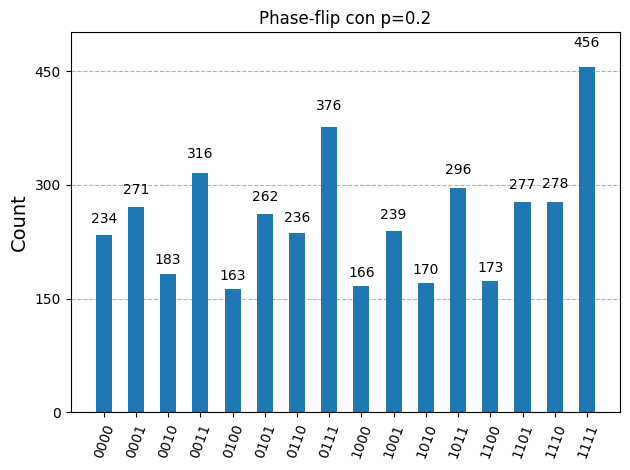

In [ ]:
# Modelo de ruido
noise_phaseflip = NoiseModel()

# Probabilidad
p_phaseflip = 0.2

# Error phase-flip de un qubit
error_phaseflip_1q = pauli_error([
    ("Z", p_phaseflip),
    ("I", 1 - p_phaseflip)
])

# Error para compuertas de dos qubits
error_phaseflip_2q = error_phaseflip_1q.tensor(
    error_phaseflip_1q
)

# Agregamos ruido a compuertas de 1 qubit
noise_phaseflip.add_all_qubit_quantum_error(
    error_phaseflip_1q,
    ["x", "h"]
)

# Agregamos ruido a CX
noise_phaseflip.add_all_qubit_quantum_error(
    error_phaseflip_2q,
    ["cx"]
)

# Simulador
sim_phaseflip = AerSimulator(
    noise_model=noise_phaseflip
)

# Transpilación
qc_phaseflip = transpile(qc, sim_phaseflip)

# Ejecución
result_phaseflip = sim_phaseflip.run(
    qc_phaseflip,
    shots=shots
).result()

# Resultados
counts_phaseflip = result_phaseflip.get_counts()

print("Resultados con Phase-flip:")
print(counts_phaseflip)

# Histograma
fig = plot_histogram(
    counts_phaseflip,
    title="Phase-flip con p=0.2"
)

display(fig)

Para este caso del phase-flip, el resultado correcto $1111$ todavía aparece como el más frecuente, pero la distribución ahora si quedo quedó mucho más dispersa entre distintos estados.

A diferencia del bit-flip, este ruido no invierte directamente los bits, sino que altera las fases relativas de los estados cuánticos.

Sinceramente no esperaba tanto cambio pero es natural pues como Bernstein-Vazirani depende de la interferencia de fases para reconstruir el string secreto, pequeñas alteraciones en las fases terminan afectando fuertemente la medición final. Por eso aparecen muchos resultados diferentes con probabilidades similares y el histograma pierde gran parte de la concentración en $1111$.

## iii. Depolarizing channel con $p = 0.01$

El canal depolarizante introduce errores aleatorios de tipo $X$, $Y$ y $Z$:

$$
\rho \mapsto (1-p)\rho + \frac{p}{3}(X\rho X + Y\rho Y + Z\rho Z)
$$


Resultados con Depolarizing:
{'1100': 1, '0010': 2, '0000': 47, '1101': 46, '0011': 20, '1011': 40, '0111': 66, '0101': 2, '1110': 53, '0001': 17, '1111': 3802}


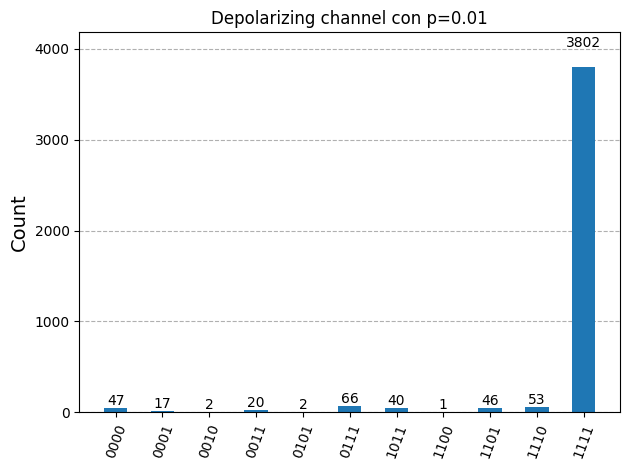

In [ ]:
# Modelo de ruido
noise_depol = NoiseModel()

# Probabilidad
p_depol = 0.01

# Error depolarizante de 1 qubit
error_depol_1q = depolarizing_error(
    p_depol,
    1
)

# Error depolarizante de 2 qubits
error_depol_2q = depolarizing_error(
    p_depol,
    2
)

# Agregamos ruido a compuertas de 1 qubit
noise_depol.add_all_qubit_quantum_error(
    error_depol_1q,
    ["x", "h"]
)

# Agregamos ruido a CX
noise_depol.add_all_qubit_quantum_error(
    error_depol_2q,
    ["cx"]
)

# Simulador
sim_depol = AerSimulator(
    noise_model=noise_depol
)

# Transpilación
qc_depol = transpile(qc, sim_depol)

# Ejecución
result_depol = sim_depol.run(
    qc_depol,
    shots=shots
).result()

# Resultados
counts_depol = result_depol.get_counts()

print("Resultados con Depolarizing:")
print(counts_depol)

# Histograma
fig = plot_histogram(
    counts_depol,
    title="Depolarizing channel con p=0.01"
)

display(fig)

Y para finalizar el caso depolarizante con (p=0.01), el resultado correcto (1111) sigue dominando claramente con 3802 mediciones de 4096, lo que indica que el algoritmo aún funciona bastante bien bajo este nivel de ruido.

Notamos que aparecen algunos estados incorrectos y como vimos su frecuencia es mucho menor comparada con el caso ideal que era perfecto. Esto ocurre porque la probabilidad de error es pequeña y, aunque el canal depolarizante introduce errores aleatorios de tipo (X), (Y) y (Z), la mayoría de las ejecuciones todavía conservan correctamente la interferencia necesaria para recuperar el string secreto.


## Todos los Resultados.

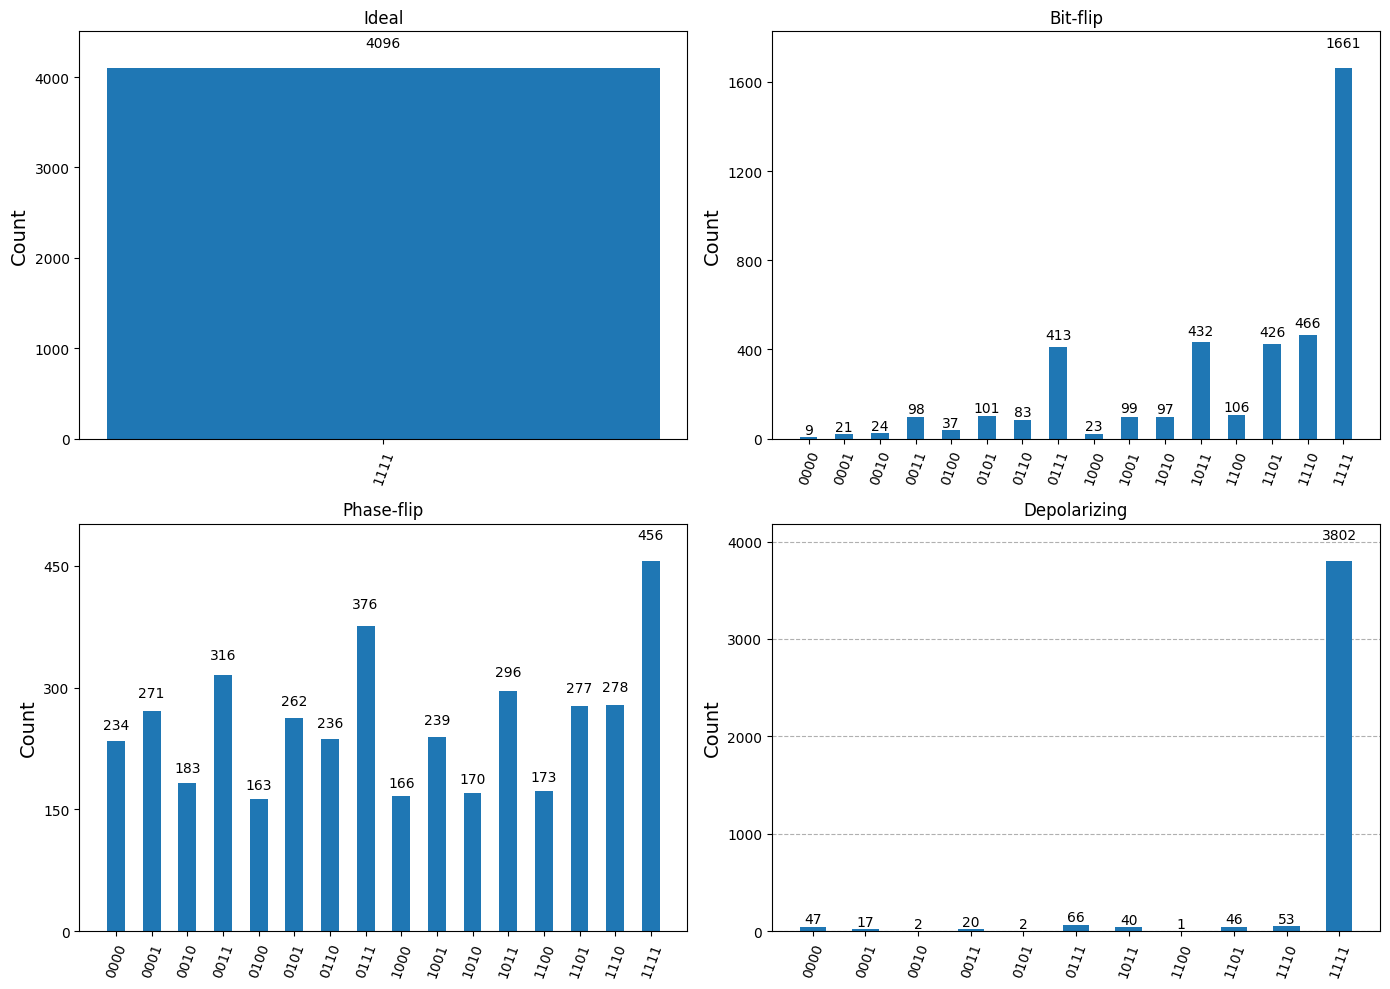

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plot_histogram(counts_ideal, ax=axs[0, 0])
axs[0, 0].set_title("Ideal")

plot_histogram(counts_bitflip, ax=axs[0, 1])
axs[0, 1].set_title("Bit-flip")

plot_histogram(counts_phaseflip, ax=axs[1, 0])
axs[1, 0].set_title("Phase-flip")

plot_histogram(counts_depol, ax=axs[1, 1])
axs[1, 1].set_title("Depolarizing")

plt.tight_layout()
plt.show()

# **1.c. ¿Existe algún canal de ruido que no se encuentre entre los primeros que mencionamos en la sesión? Investigalo, explicalo e implementalo utilizando los operadores de Kraus que correspondan a dicho canal y explica los resultados**

In [ ]:
from qiskit_aer.noise import reset_error

Sí, en este caso decidí el **Reset Error Channel**, que por lo que comprendí es un modelo de ruido en el que un qubit puede perder completamente su estado cuántico y ser reinicializado a $\vert 0\rangle$ o $\vert 1\rangle$ con cierta probabilidad. Esto no solo altera una propiedad específica del qubit (como los anteriores), sino que puede borrar directamente la información almacenada en él, afectando significativamente el comportamiento del algoritmo cuántico.

In [ ]:
# Modelo de ruido vacío
noise_reset = NoiseModel()

# Probabilidades de reset
p0 = 0.05  # probabilidad de resetear a |0>
p1 = 0.05  # probabilidad de resetear a |1>

# Error de reset de 1 qubit
error_reset_1q = reset_error(p0, p1)

# Para compuertas de 2 qubits usamos el producto tensorial
error_reset_2q = error_reset_1q.tensor(error_reset_1q)

Eso significa:

$$
p_0 = 0.05, \quad p_1 = 0.05
$$

donde $p_0$ es la probabilidad de resetear a $\vert 0\rangle$ y $p_1$ la probabilidad de resetear a $\vert 1\rangle$.

La probabilidad restante,

$$
1 - p_0 - p_1 = 0.90,
$$

corresponde a que no ocurra reset.

Resultados con Reset Error:
{'0100': 41, '1100': 61, '0111': 393, '0011': 171, '1011': 319, '1110': 255, '1111': 1776, '0001': 156, '1101': 297, '0101': 70, '1001': 73, '0110': 75, '1000': 50, '0000': 230, '0010': 56, '1010': 73}


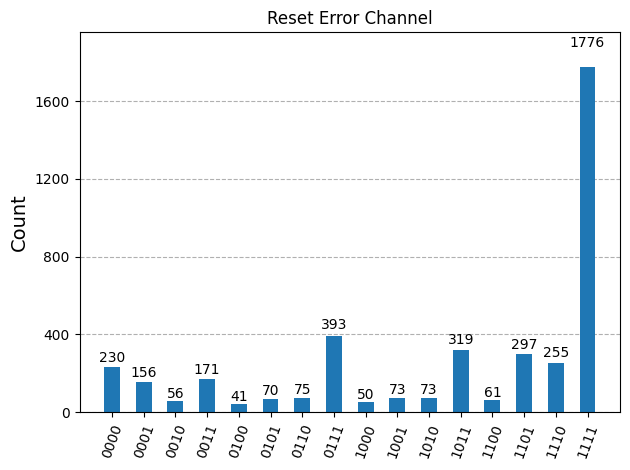

In [ ]:
# Agregamos el reset error a compuertas de 1 qubit
noise_reset.add_all_qubit_quantum_error(
    error_reset_1q,
    ["x", "h"]
)

# Agregamos el reset error a compuertas de 2 qubits
noise_reset.add_all_qubit_quantum_error(
    error_reset_2q,
    ["cx"]
)

# Simulador con reset error
sim_reset = AerSimulator(noise_model=noise_reset)

# Transpilamos
qc_reset = transpile(qc, sim_reset)

# Ejecutamos
result_reset = sim_reset.run(
    qc_reset,
    shots=shots
).result()

# Resultados
counts_reset = result_reset.get_counts()

print("Resultados con Reset Error:")
print(counts_reset)

# Histograma
fig = plot_histogram(
    counts_reset,
    title="Reset Error Channel"
)

display(fig)

Y vemos que el caso del Reset Error Channel, el resultado correcto (1111) sigue siendo el más frecuente, pero el histograma se dispersa considerablemente entre muchos otros estados.

Y como ya mencionaba, esto ocurre porque el canal puede reinicializar algunos qubits a $|0\rangle$ o $|1\rangle$ durante la ejecución del circuito, provocando una pérdida directa de la información almacenada.

# **2.a. Aplica el algoritmo de Grover para $\vert 1111\rangle$ y para $\vert 1110\rangle$ sin utilizar las funciones dadas para el oráculo de Grover y para el difusor de Grover; en su lugar, explica desde cero cómo realizaste el cambio de base para poder simular la operación del oráculo y del difusor. Realiza las iteraciones necesarias.**

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt

El espacio de búsqueda tiene:

$$
N = 2^4 = 16
$$

y para un único estado marcado, el número óptimo de iteraciones es:

$$
r \approx \left\lfloor \frac{\pi}{4} \sqrt{16} \right\rfloor = 3
$$

In [ ]:
# Número de qubits
n = 4

# Número de mediciones
shots = 1024

# Simulador
sim = AerSimulator()

Toca aramrlo desde cero, así que se comienza preparando una superposición  sobre todos los estados posibles aplicando compuertas Hadamard a cada qubit.

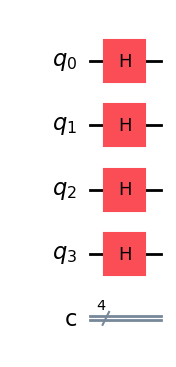

In [ ]:
# Circuito
qc = QuantumCircuit(n, n)

# Superposición
qc.h(range(n))

qc.draw("mpl")

Lo que sigue es el oráculo, i. e. es invertir únicamente la fase del estado buscado:

$$
\vert w \rangle \rightarrow -\vert w \rangle
$$

In [ ]:
def oraculo_1111(qc):

    # Convertimos MCX en MCZ usando H
    qc.h(3)

    # Multi-Control X
    qc.mcx([0,1,2], 3)

    # Regresamos la base
    qc.h(3)

La compuerta multicontrolada utilizada marca naturalmente al estado $\vert 1111 \rangle$. Por ello, si se desea marcar otro estado, se realiza un cambio de base usando compuertas $X$. Pero en este caso $\vert 1111 \rangle$, no es necesario realizar ningún cambio de base.



Ahora, para el estado $\vert 1110 \rangle$, el último bit es $0$. Entonces se aplica una compuerta $X$ para transformar temporalmente:

$$
\vert 1110 \rangle \rightarrow \vert 1111 \rangle
$$

Después de aplicar la inversión de fase, se deshace el cambio.

In [ ]:
def oraculo_1110(qc):

    # Cambio de base:|1110> -> |1111>
    qc.x(0)

    # MCZ
    qc.h(3)
    qc.mcx([0,1,2], 3)
    qc.h(3)

    # Deshacer cambio de base
    qc.x(0)

Ahora sigue el difusor de Grover, el cual amplifica la amplitud del estado marcado reflejando las amplitudes respecto al promedio.

El operador utilizado es:

$$
D = H^{\otimes 4} X^{\otimes 4} (2\vert 1111 \rangle \langle 1111 \vert - I) X^{\otimes 4} H^{\otimes 4}
$$

La implementación es:

In [ ]:
def difusor(qc):

    # H sobre todos los qubits
    qc.h(range(n))

    # X sobre todos los qubits
    qc.x(range(n))

    # MCZ
    qc.h(3)
    qc.mcx([0,1,2], 3)
    qc.h(3)

    # Deshacer X
    qc.x(range(n))

    # Deshacer H
    qc.h(range(n))

Con el oráculo y el difusor construidos, se aplican las iteraciones de Grover. Para $4$ qubits se utilizan $3$ iteraciones.



Para $\vert 1111 \rangle$:

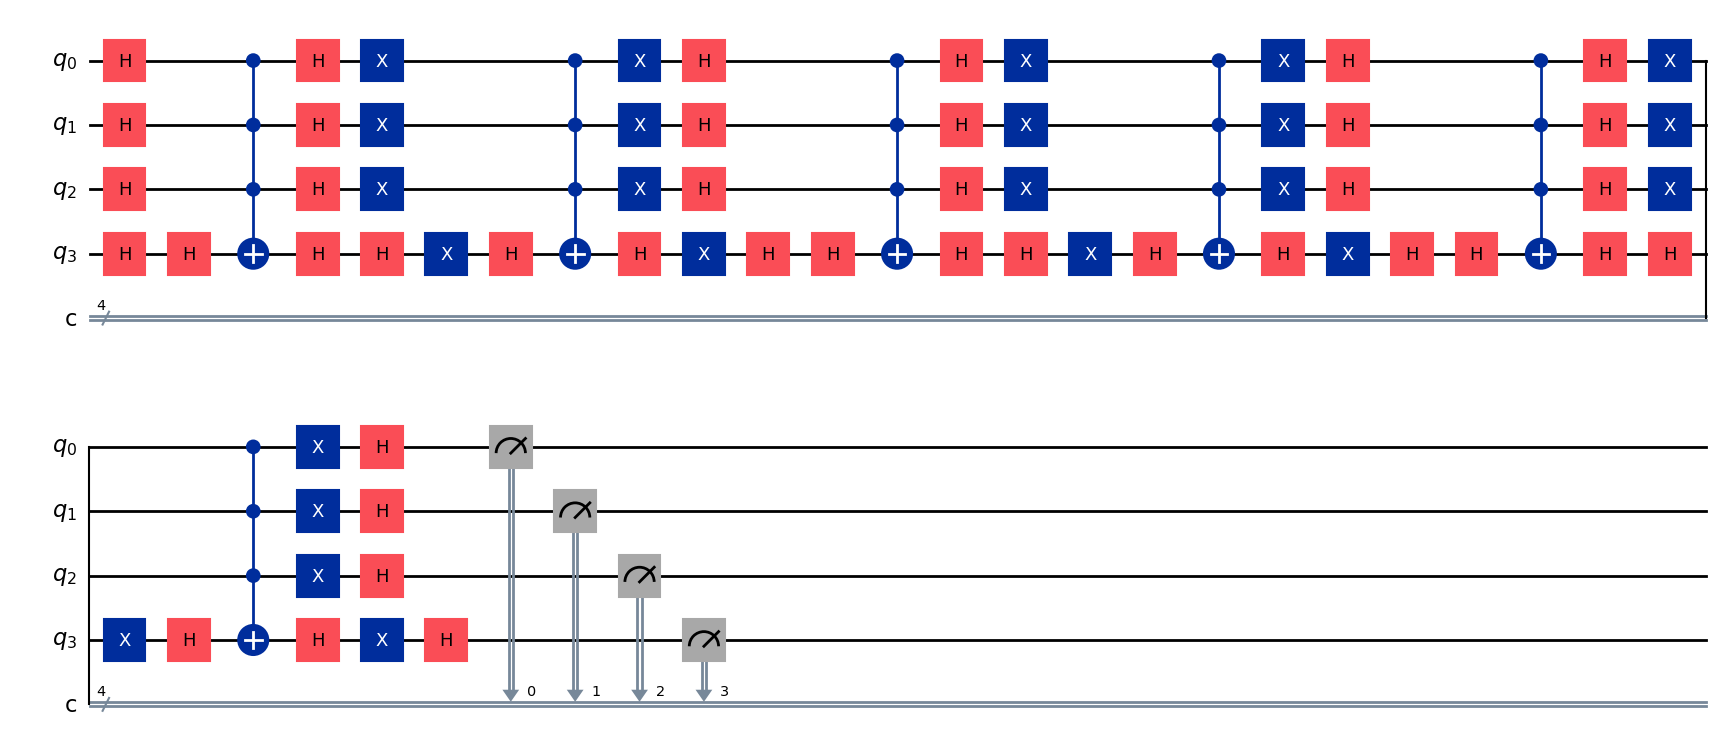

In [ ]:
qc_1111 = QuantumCircuit(n, n)

# Superposición inicial
qc_1111.h(range(n))

# 3 iteraciones de Grover
for _ in range(3):

    # Oráculo
    oraculo_1111(qc_1111)

    # Difusor
    difusor(qc_1111)

# Mediciones
qc_1111.measure(range(n), range(n))

qc_1111.draw("mpl")

{'0000': 2, '1111': 988, '1101': 3, '0100': 3, '0111': 1, '0011': 3, '1011': 2, '0110': 4, '1000': 3, '1100': 2, '1010': 1, '1001': 2, '0101': 4, '1110': 2, '0010': 4}


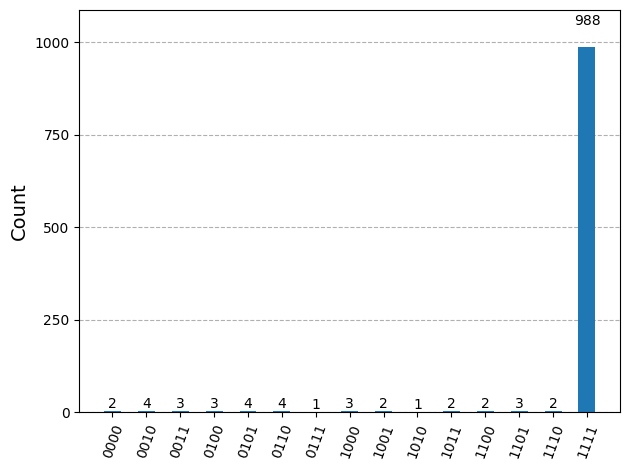

In [ ]:
from qiskit.visualization import plot_histogram
from IPython.display import display

compiled = transpile(qc_1111, sim)
result = sim.run(compiled, shots=shots).result()

counts = result.get_counts()

print(counts)

hist = plot_histogram(counts)

display(hist)

Para $\vert 1110 \rangle$:

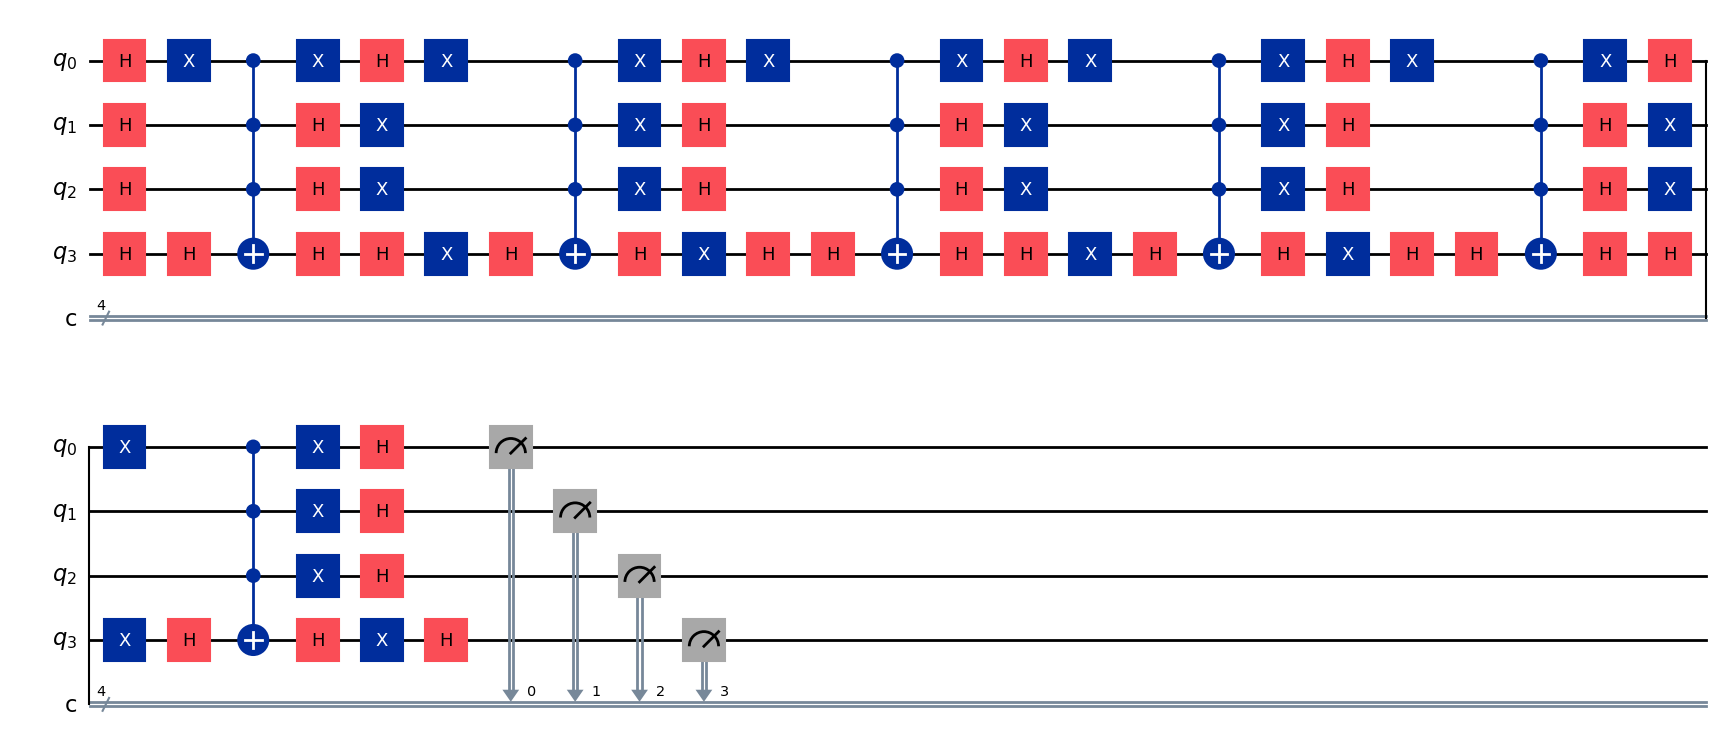

In [ ]:
qc_1110 = QuantumCircuit(n, n)

# Superposición inicial
qc_1110.h(range(n))

# Iteraciones de Grover
for _ in range(3):

    # Oráculo para |1110>
    oraculo_1110(qc_1110)

    # Difusor
    difusor(qc_1110)

# Mediciones
qc_1110.measure(range(n), range(n))

qc_1110.draw("mpl")

{'1010': 1, '1111': 2, '1110': 986, '1100': 3, '0101': 1, '1001': 4, '1011': 3, '0111': 3, '0011': 2, '0000': 5, '0010': 3, '0100': 3, '1000': 3, '0110': 2, '1101': 3}


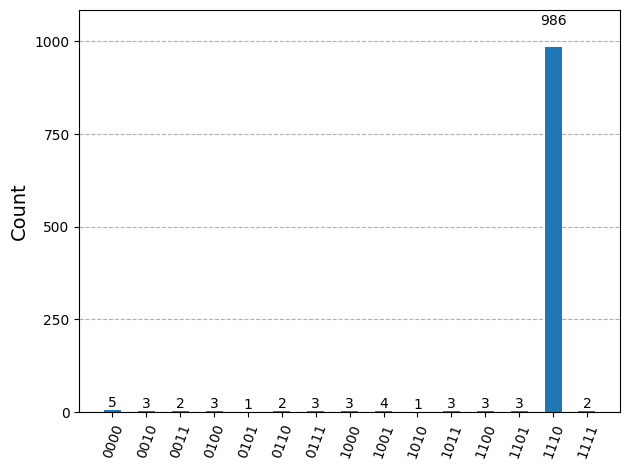

In [ ]:
from IPython.display import display

compiled = transpile(qc_1110, sim)
result = sim.run(compiled, shots=shots).result()

counts = result.get_counts()

print(counts)

hist = plot_histogram(counts)

display(hist)

En ambos casos, el algoritmo de Grover funcionó correctamente, ya que el estado objetivo fue el más probable en las mediciones. Para $\vert 1111 \rangle$ se obtuvieron $988$ resultados correctos y para $\vert 1110 \rangle$ se obtuvieron $989$ de $1024$ mediciones. Esto muestra que el oráculo y el difusor implementados manualmente amplificaron correctamente la probabilidad del estado marcado.

# **2.b. Corre el algoritmo de Grover para encontrar el número de tu preferencia, pero aplica el operador de Grover una cantidad mayor de veces que la predicha por la teoría mencionada en el Notebook. ¿Qué pasa? ¿Hay algún cambio en las probabilidades? Explica por qué ocurre el cambio que observas en las probabilidades.**

Para este inciso elegí nuevamente el estado $\vert 1111 \rangle$. En el caso anterior, para $4$ qubits, el número óptimo de iteraciones era aproximadamente:

$$
r \approx \left\lfloor \frac{\pi}{4} \sqrt{16} \right\rfloor = 3
$$

Ahora la idea es aplicar el operador de Grover más veces de las necesarias para observar cómo cambian las probabilidades.

Primero construí el circuito usando $6$ iteraciones en lugar de $3$.

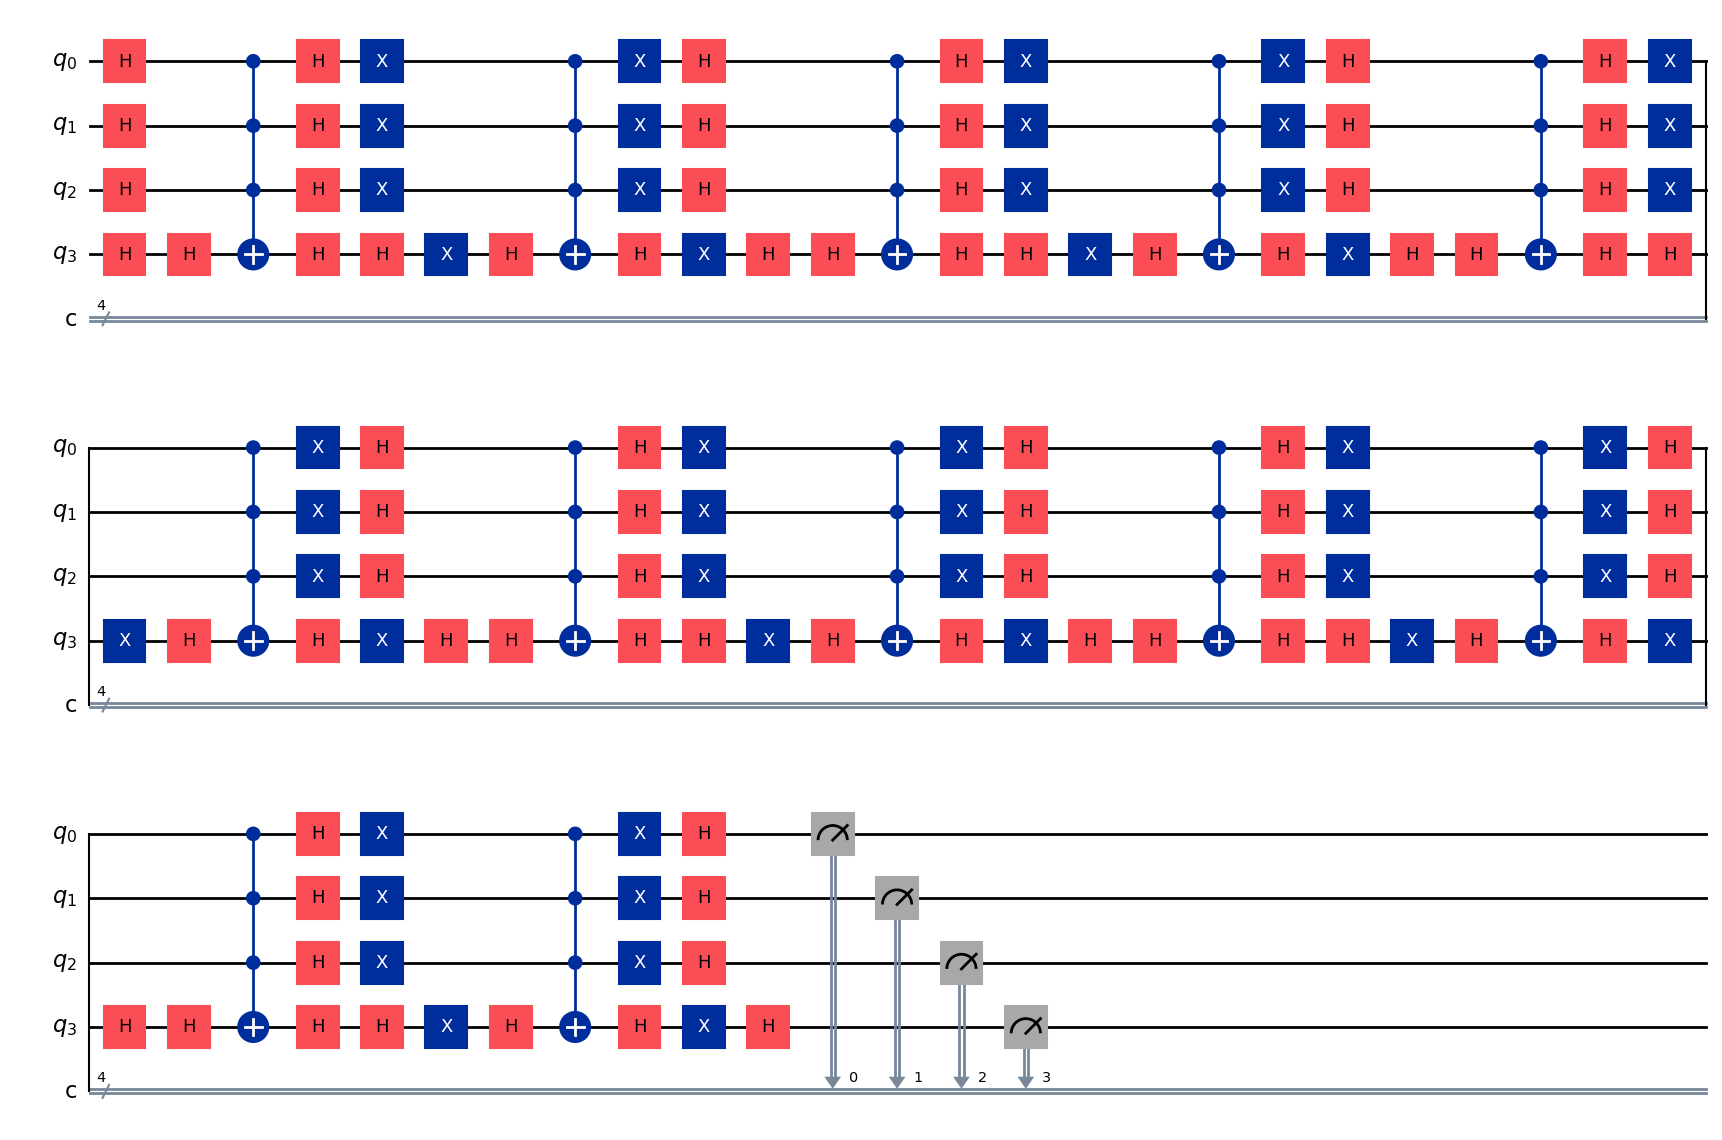

In [ ]:
qc_extra = QuantumCircuit(n, n)

# Superposición inicial
qc_extra.h(range(n))

# Más iteraciones de las óptimas
for _ in range(6):

    # Oráculo para |1111>
    oraculo_1111(qc_extra)

    # Difusor
    difusor(qc_extra)

# Mediciones
qc_extra.measure(range(n), range(n))

qc_extra.draw("mpl")

{'1111': 22, '0001': 61, '1101': 64, '1110': 62, '0000': 60, '0010': 54, '1011': 75, '0111': 72, '0011': 72, '1010': 64, '0110': 78, '1000': 51, '1100': 63, '0101': 73, '1001': 82, '0100': 71}


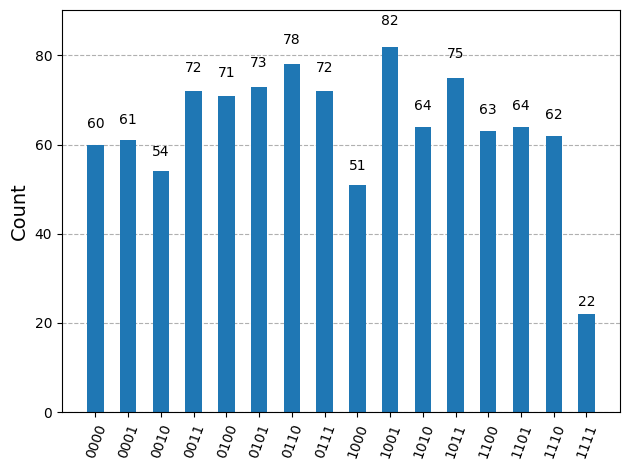

In [ ]:
from IPython.display import display

compiled = transpile(qc_extra, sim)
result = sim.run(compiled, shots=shots).result()

counts_extra = result.get_counts()

print(counts_extra)

hist = plot_histogram(counts_extra)

display(hist)

Directamente vemos que si hubo un cambio importante en las probabilidades. Al aplicar más iteraciones de las necesarias, el estado correcto $\vert 1111 \rangle$ dejó de ser el dominante y solo apareció $22$ veces de $1024$ mediciones, mientras que las probabilidades comenzaron a repartirse entre muchos otros estados.

Esto ocurre porque Grover amplifica la amplitud del estado solución solo hasta cierto punto y después del número óptimo de iteraciones, el algoritmo se pasa de la solución y la amplitud del estado correcto vuelve a disminuir.

# **2.c. Implementa algún modelo de ruido cuántico en las compuertas de 1 qubit del algoritmo de Grover, con probabilidad $p = 0.01$, y visualiza cómo cambia la implementación del algoritmo y si ahora funciona correctamente. Haz las comparaciones utilizando histogramas y explica por qué crees que mediste esos resultados.**

Para este inciso agregué un modelo de ruido cuántico al algoritmo de Grover. En particular, usé un canal de error tipo depolarizing error sobre las compuertas de 1 qubit, con probabilidad:

p=0.01

La idea es comparar el resultado ideal contra el resultado con ruido, para ver si el estado objetivo sigue siendo el más probable.

Agregué el error a compuertas como $X$ y $H$, que son las que usamos en el oráculo, el cambio de base y el difusor.

In [ ]:
# Probabilidad de error
p = 0.01

# Modelo de ruido
noise_model = NoiseModel()

# Error depolarizante para compuertas de 1 qubit
error_1q = depolarizing_error(p, 1)

# Agregamos el ruido a compuertas de 1 qubit usadas en el circuito
noise_model.add_all_qubit_quantum_error(error_1q, ["x", "h"])

# Simulador con ruido
sim_ruido = AerSimulator(noise_model=noise_model)

{'0100': 11, '1011': 36, '0111': 33, '0011': 18, '1111': 745, '0001': 11, '0110': 8, '1000': 17, '1100': 14, '0101': 8, '1001': 12, '1101': 37, '1110': 41, '0000': 13, '0010': 11, '1010': 9}


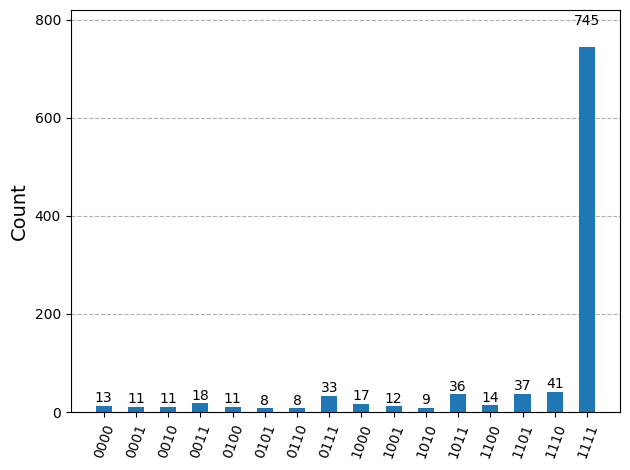

In [ ]:
compiled_ruido = transpile(qc_1111, sim_ruido)
result_ruido = sim_ruido.run(compiled_ruido, shots=shots).result()

counts_ruido = result_ruido.get_counts()

print(counts_ruido)

hist = plot_histogram(counts_ruido)
display(hist)

Sí hubo un cambio en las probabilidades al agregar ruido con $p = 0.01$. El estado correcto $\vert 1111 \rangle$ siguió siendo el más probable con $745$ mediciones, pero su frecuencia disminuyó respecto al caso ideal y aumentaron las mediciones en estados incorrectos. Esto ocurre porque el ruido altera las amplitudes y fases del sistema, haciendo menos eficiente la amplificación de amplitud de Grover, aunque el algoritmo todavía conserva parcialmente su funcionamiento esperado.